# 03 — Classical Models

Four classical models are trained on the official 561 features and compared on
the subject-independent test set:

- Logistic Regression (a linear baseline)
- Random Forest
- Gradient Boosting
- SVM with an RBF kernel

Every number here is measured on the 9 test subjects, none of whom appear in
training. Results lead with macro-F1 because the classes are mildly imbalanced,
and the confusion matrix at the end is checked against the prediction from the
EDA: sitting and standing should be the main source of error.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_features, ACTIVITY_LABELS
from src.models import get_classical_models
from src.evaluate import evaluate_model, plot_confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

X_train, y_train, _ = load_features("train")
X_test,  y_test,  _ = load_features("test")
class_names = [ACTIVITY_LABELS[i] for i in range(1, 7)]

print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (7352, 561)   Test: (2947, 561)


## 1. Train and evaluate all four models

Each model is fit on the training set and scored on the test set. Scaling for the
linear and kernel models happens inside their pipelines, fit on training data
only, so no test information leaks in.

In [2]:
models = get_classical_models()
results = {}

for name, model in models.items():
    res = evaluate_model(model, X_train, y_train, X_test, y_test)
    results[name] = res
    print(f"{name:22s} acc={res['accuracy']:.3f}  "
          f"macro-F1={res['macro_f1']:.3f}  fit={res['fit_time_s']:.1f}s")

Logistic Regression    acc=0.955  macro-F1=0.955  fit=2.1s


Random Forest          acc=0.926  macro-F1=0.924  fit=33.9s


Gradient Boosting      acc=0.933  macro-F1=0.933  fit=39.7s


SVM (RBF)              acc=0.955  macro-F1=0.954  fit=2.5s


## 2. Results table

Sorted by macro-F1. Fit time is included because it is part of the story: on a
dataset this size, the models that top the table are not necessarily the ones
you would reach for if training cost mattered.

In [3]:
table = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": res["accuracy"],
        "Macro-F1": res["macro_f1"],
        "Fit time (s)": res["fit_time_s"],
    }
    for name, res in results.items()
]).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

# Save for the README / report.
results_dir = Path.cwd().parent / "results"
table.to_csv(results_dir / "metrics.csv", index=False)

table.round(3)

,Model,Accuracy,Macro-F1,Fit time (s)
0,Logistic Regression,0.955,0.955,2.149
1,SVM (RBF),0.955,0.954,2.474
2,Gradient Boosting,0.933,0.933,39.736
3,Random Forest,0.926,0.924,33.910


The models cluster within a couple of points of each other. A linear model does
most of the job on its own, which tells us the 561 engineered features are
already doing the heavy lifting — they were designed to make the classes close to
linearly separable. The extra capacity of the ensembles and the RBF kernel buys
only a small gain on top.

## 3. Confusion matrix of the best model

Row-normalised, so each cell is the fraction of a true activity predicted as each
class (the diagonal is per-class recall). This is where the EDA prediction gets
tested.

Best model: Logistic Regression


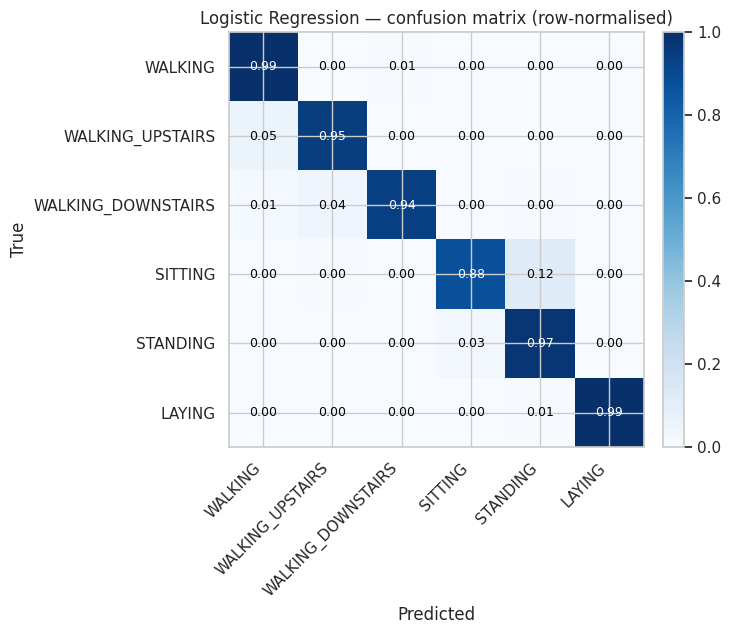

In [4]:
best_name = table.iloc[0]["Model"]
best = results[best_name]
print(f"Best model: {best_name}")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
plot_confusion_matrix(
    y_test, best["preds"], class_names,
    title=f"{best_name} — confusion matrix (row-normalised)",
    normalize=True, ax=ax,
    save_path=str(results_dir / "confusion_matrices" / "best_model.png"),
)
plt.show()

The moving activities are recognised almost perfectly, and laying is essentially
never missed. The errors concentrate exactly where the EDA said they would: the
**sitting / standing** pair. The confusion is asymmetric — about one sitting
window in eight is predicted as standing, while standing is misread as sitting
only rarely. That is the direct consequence of what we saw earlier: with movement
removed, the two postures differ only by a subtle, subject-dependent orientation
cue, and on unseen subjects that cue does not fully transfer.

This is the payoff of evaluating subject-independently. A random-split evaluation
would have hidden this error behind inflated accuracy; here it surfaces honestly,
and it matches the physical explanation.

## 4. Per-class detail for the best model

The confusion matrix summarised visually; here are the exact precision, recall
and F1 for each activity.

In [5]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test, best["preds"], target_names=class_names, output_dict=True
)
per_class = pd.DataFrame(report).T.loc[class_names, ["precision", "recall", "f1-score"]]
per_class.round(3)

,precision,recall,f1-score
WALKING,0.943,0.994,0.968
WALKING_UPSTAIRS,0.959,0.947,0.953
WALKING_DOWNSTAIRS,0.990,0.940,0.965
SITTING,0.968,0.876,0.920
STANDING,0.890,0.974,0.930
LAYING,0.998,0.993,0.995


The asymmetry is visible in the numbers: **sitting** has the lowest recall (many
sitting windows are missed), while **standing** has the lowest precision (it
absorbs those misread sitting windows). Every other activity scores well above
both.

## Takeaways

- All four models land within a few points of each other on unseen subjects; the
  engineered features do most of the work, so even a linear model is strong — and
  here the linear model is both the most accurate and the fastest to train.
- The single consistent error is **sitting vs standing**, and it is asymmetric:
  sitting is predicted as standing far more often than the reverse, exactly as the
  EDA predicted from the physics of the signal.
- Reporting this openly, rather than hiding it behind a leaky random split, is
  the point of the subject-independent setup.
- Step 4 asks whether a deep model on the **raw** signals — no hand-engineered
  features — can match these numbers, and whether it makes the same mistake.